In [17]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget

In [18]:
project_name = "syn"
condition = "3mod"
data = "biased_00"
switch_epoch = 0

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
samples = get_data_samples(data_module, n_samples, split ='train')

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_biased_00/checkpoints/last.ckpt


In [19]:
unimodal_latents = global_workspace.encode_domains(samples)

# premier encodage: on reconstitue les attributs à partir du module vision
gw_latents = global_workspace.encode(unimodal_latents)

a2_from_v = split_softmax_category_attributes(
    global_workspace.decode(
        gw_latents[frozenset({'v_latents', 'attr'})]
        )['v_latents']['attr']
    )

# second encodage: on récupère les v_latents a partir des attributs
gw_latents_2 = global_workspace.encode({'attr': {'attr': torch.cat((a2_from_v[0], a2_from_v[1]), dim = 1)}})

v2_from_a2 = global_workspace.decode(
        gw_latents_2['attr']
        )['attr']['v_latents']

# troisième encodage: on reconstitue les attributs à partir du module vision
gw_latents_3 = global_workspace.encode({'v_latents': {'v_latents': v2_from_a2}})

a3_from_v2 = split_softmax_category_attributes(global_workspace.decode(
        gw_latents_3['v_latents']
        )['v_latents']['attr']
)

In [20]:
#torch.argmax(samples[frozenset({'v_latents', 'attr'})]['attr'][0], dim=1)
samples[frozenset({'v_latents', 'attr'})]['attr']

tensor([[-0.4444, -0.1111, -0.7143, -0.6711,  0.7413],
        [ 0.8889,  0.5556,  0.7143,  0.2991, -0.9542],
        [-0.7778, -0.6667, -0.7143,  0.6047, -0.7965],
        [ 0.1111, -0.3333,  0.1429, -0.8630, -0.5052],
        [-1.0000, -0.5556, -0.7143,  0.7504,  0.6610],
        [-0.2222,  0.2222, -0.1429, -0.3079,  0.9514],
        [-1.0000, -0.3333,  0.4286,  0.8590, -0.5119],
        [-0.1111,  0.3333,  0.1429, -0.9438, -0.3304],
        [ 0.8889,  0.4444, -0.1429,  0.2345, -0.9721],
        [ 0.1111, -0.8889,  0.7143, -0.9187,  0.3949],
        [ 0.8889,  0.1111,  0.4286, -0.0901, -0.9959],
        [ 0.2222, -0.5556,  0.1429, -0.2718,  0.9623],
        [-0.1111,  0.3333,  0.4286,  0.8132,  0.5820],
        [-0.5556,  0.7778, -1.0000, -0.9775, -0.2112],
        [-1.0000,  0.6667, -0.1429, -0.8993,  0.4373],
        [ 0.6667, -1.0000, -1.0000,  0.9575, -0.2884],
        [-0.2222, -0.8889,  0.7143,  0.9911, -0.1330],
        [ 0.4444, -0.8889,  0.1429,  0.8481,  0.5298],
        [-

In [21]:
#torch.argmax(a3_from_v2[0], dim = 1)
global_workspace.decode(
        gw_latents[frozenset({'v_latents', 'attr'})]
        )['v_latents']['attr']

tensor([[-1.4425e+00, -6.3549e-02, -8.1423e-01, -9.8703e-01,  6.3898e-01],
        [ 2.5743e+00,  1.7790e+00,  1.8196e+00,  5.8911e-01, -9.0556e-01],
        [-1.5243e+00, -8.5456e-01, -1.9758e-01, -5.2503e-01, -1.1599e-01],
        [-1.5174e-01, -6.0065e-01,  1.1892e+00, -3.9766e-01, -5.1785e-01],
        [-1.3447e+00, -5.5585e-01, -3.6811e-01,  1.2339e-01,  3.7953e-01],
        [ 2.7079e-01,  5.6477e-01, -3.8677e-01,  2.2050e-01,  5.7800e-01],
        [-1.7080e+00, -1.0021e+00,  6.6103e-01,  5.0286e-01, -8.7857e-01],
        [ 3.7858e-01,  2.6403e+00, -6.7951e-01, -7.3077e-01, -6.8037e-01],
        [ 2.7363e+00,  1.9054e+00, -1.8078e-01,  7.5324e-01, -2.7595e-01],
        [ 3.9364e-01, -8.1530e-01,  1.3596e+00, -8.7443e-01, -3.0548e-01],
        [ 1.3500e+00,  1.1020e-02,  6.8387e-01, -3.7976e-01, -9.4824e-01],
        [ 9.2851e-01, -8.2493e-01, -1.6551e-01, -8.3156e-01,  3.2529e-01],
        [-3.1350e-01,  1.2380e+00,  2.2955e+00,  5.8250e-01,  7.0057e-01],
        [-2.5719e-01,  3.

In [22]:
training_params

{'experiment_name': '3mod_biased_00',
 'exclude_colors': True,
 'apply_custom_init': True,
 'config': Config(seed=126, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='/home/lucas/gwsyn/simple_shapes_dataset_biased_00'), training=Training(batch_size=2000, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=200000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, log_val_medias_eve

In [23]:
def get_n_per_category(source_tensor, current_attr, n_per_cat=5):
    """
    Retourne les n premiers éléments de source_tensor pour chaque catégorie 
    définie dans current_attr.
    
    Args:
        source_tensor: Le tenseur d'où on extrait les données (ex: des images ou latents)
        current_attr: Le tenseur de catégories (one-hot, ex: [Batch, 3])
        n_per_cat: Nombre d'éléments à extraire par catégorie
    """
    # 1. Convertir le one-hot en indices (0, 1, 2)
    labels = current_attr.argmax(dim=-1)
    
    # 2. Trouver les indices pour chaque classe
    indices_list = []
    num_classes = current_attr.shape[-1]
    
    for i in range(num_classes):
        # On récupère les indices où la classe est i
        indices = (labels == i).nonzero(as_tuple=True)[0]
        
        if len(indices) < n_per_cat:
            print(f"Warning: Seulement {len(indices)} éléments trouvés pour la classe {i}")
            indices_list.append(indices)
        else:
            # On ne garde que les n premiers
            indices_list.append(indices[:n_per_cat])
    
    # 3. Concaténer tous les indices sélectionnés
    all_indices = torch.cat(indices_list)
    
    # 4. Retourner le sous-ensemble du tenseur source
    return source_tensor[all_indices]

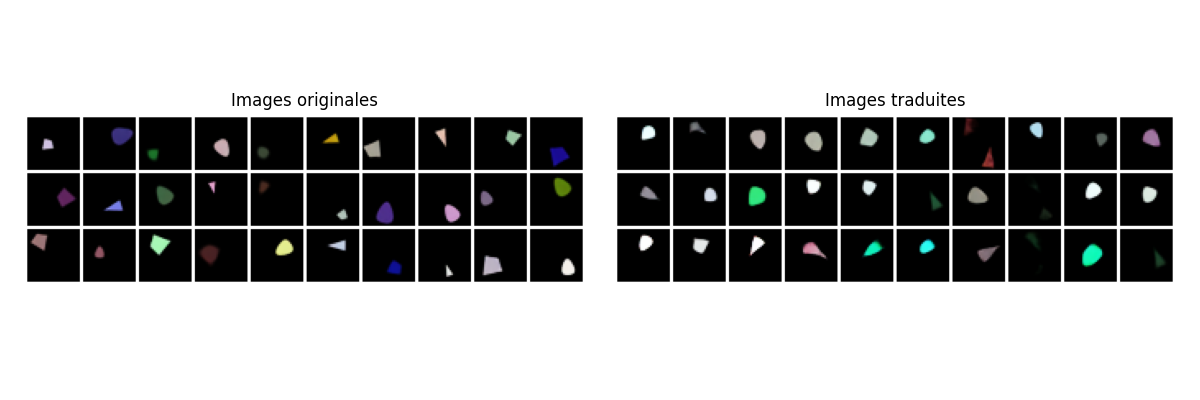

In [ ]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_rgb = visual_module.decode_images(v2_from_a2)
original_images = samples[frozenset({'attr', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)

import matplotlib.pyplot as plt

current_attr = samples[frozenset({'cat', 'v_latents'})]['cat']
fig = plot_original_translated_comparison(original_images_rgb, decoded_images_rgb)
plt.show()
